In [6]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [7]:
import copy
import os,sys
os.chdir('/Users/levgolod/Projects/car_classifier/')

In [8]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import OneHotEncoder


import pandas as pd
# import tensorflow.compat.v1 as tf

In [9]:
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



In [10]:
from _02_preprocess_data.preprocess_data_fns import *

In [11]:
IMAGE_SIZE = 256 # increase later
SAMPLE_SIZE = 10000 # increase later

class_names_use = ['sedan','suv','truck']
label_dict = {v:k for k,v in body_style_dict.items()}
print(label_dict)
class_names = list(label_dict.values())
class_labels_use = list([v for k,v in body_style_dict.items() if k in class_names_use])
class_labels_use

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}


[0, 2, 3]

### Ingest image data from disk

In [12]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
df=df.loc[df['body_style'].isin(class_names_use), ].reset_index()
print(df.shape)
print(df.partition.value_counts(dropna=False,normalize=True))
df.head()

(7768, 10)
partition
train    0.718589
hold     0.147915
val      0.133496
Name: proportion, dtype: float64


,index,filepath,filename,filepath_to_use,vehicle_id,partition,make,model,body_style,body_style_index
0,2748,/Users/levgolod/Projects/car_classifier/data/a...,1f639ccfbc5d4a10a6244d30c83c3f8c.jpg,/Users/levgolod/Projects/car_classifier/data/a...,730480075,train,ford,f150,truck,3
1,857,/Users/levgolod/Projects/car_classifier/data/a...,dfe210b4b2f14896b8e57c75607e1c7a.jpg,/Users/levgolod/Projects/car_classifier/data/a...,738542219,hold,bmw,4-series,sedan,0
2,2107,/Users/levgolod/Projects/car_classifier/data/a...,02f1b871730d481c8dac18ce059754b2.jpg,/Users/levgolod/Projects/car_classifier/data/a...,731841507,train,ford,explorer,suv,2
3,286,/Users/levgolod/Projects/car_classifier/data/a...,8ffcc9fd0eb44a269f1bf1177df5f3b3.jpg,/Users/levgolod/Projects/car_classifier/data/a...,736803116,hold,bmw,3-series,sedan,0
4,772,/Users/levgolod/Projects/car_classifier/data/a...,34d7176a2af8455a93352464815a156b.jpg,/Users/levgolod/Projects/car_classifier/data/a...,736034794,train,bmw,4-series,sedan,0


In [13]:
train_dataset = process_image_files(
    df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

test_dataset = process_image_files(
    df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

holdout_dataset = process_image_files(
    df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
    image_size=IMAGE_SIZE,
)

print(len(train_dataset),len(test_dataset),len(holdout_dataset))

5582 1037 1149


In [14]:
train_images, train_labels = \
    [x[0] for x in train_dataset], [x[1] for x in train_dataset]

test_images, test_labels = \
    [x[0] for x in test_dataset], [x[1] for x in test_dataset]

holdout_images, holdout_labels = \
    [x[0] for x in holdout_dataset], [x[1] for x in holdout_dataset]

## coerce to array - data
train_images = np.array([np.array(x) for x in train_images])
test_images = np.array([np.array(x) for x in test_images])
holdout_images = np.array([np.array(x) for x in holdout_images])

## coerce to array - labels
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
holdout_labels = np.array(holdout_labels)

In [15]:
train_images.shape

(5582, 256, 256)

### create perturbations to expand the training data

In [16]:
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=[0.8, 1.0]
)

In [17]:
X_train, y_train = copy.deepcopy(train_images), copy.deepcopy(train_labels)


X_train = X_train.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)
X_train.shape

(5582, 256, 256, 1)

In [18]:
augmented_images = []
augmented_labels = []

for i in range(len(X_train)):
    img = X_train[i].reshape((1, IMAGE_SIZE, IMAGE_SIZE, 1))  # Add batch dimension
    augmented = datagen.flow(img, batch_size=1)

    for _ in range(5):  # Generate 5 augmented images per original
        aug_img = next(augmented)[0]
        augmented_images.append(aug_img)
        augmented_labels.append(y_train[i])

# Convert back to NumPy arrays
X_aug = np.array(augmented_images)
y_aug = np.array(augmented_labels)


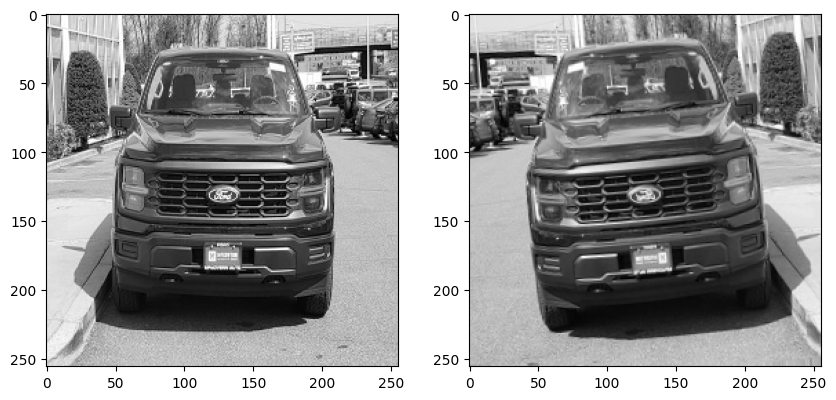

In [19]:
# show original image and then corresponding augmented image
i=0
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(np.squeeze(train_images[i]), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(np.squeeze(augmented_images[int(i*5)+1]), cmap='gray')

In [20]:
## recombine and reshape the data

X_train =np.concatenate((X_train, X_aug), axis=0)
X_train = X_train.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

train_labels = np.concatenate((train_labels, y_aug), axis=0)


In [21]:
X_train.shape
train_labels.shape
train_images = X_train
train_images.shape, test_labels.shape

((33492, 256, 256), (1037,))

In [22]:
train_images = train_images/255.0
test_images = test_images/255.0
holdout_images = holdout_images/255.0

In [23]:
pd.Series(train_labels).map(label_dict)
pd.Series(train_labels).map(label_dict).value_counts(normalize=True)
# to_categorical(pd.Series(train_labels).map(label_dict), num_classes=len(class_names_use))

sedan    0.511645
truck    0.306342
suv      0.182014
Name: proportion, dtype: float64

In [24]:
encoder = OneHotEncoder(sparse=False)
train_labels_onehot = encoder.fit_transform(np.array(pd.Series(train_labels).map(label_dict)).reshape(-1,1))
test_labels_onehot = encoder.fit_transform(np.array(pd.Series(test_labels).map(label_dict)).reshape(-1,1))
holdout_labels_onehot = encoder.fit_transform(np.array(pd.Series(holdout_labels).map(label_dict)).reshape(-1,1))


/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [25]:
train_labels_onehot.mean(axis=0)

array([0.51164457, 0.18201362, 0.30634181])

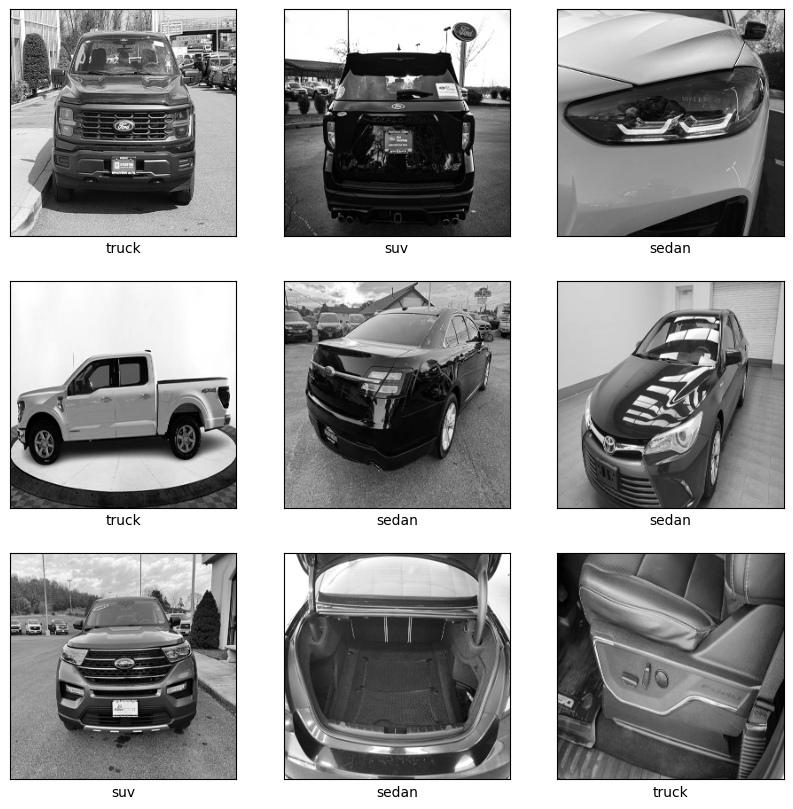

In [26]:
N=3
plt.figure(figsize=(10,10))
for i in range(N**2):
    plt.subplot(N,N,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(train_images[i]), cmap='gray')
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [29]:
metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

def create_model(
        input_shape:tuple,
        num_classes:int,
        metrics:list,
    filter_size:int=3

):
    filter_shape = (filter_size, filter_size)

    model = tf.keras.Sequential([
        # Convolutional Layer 1: Learn low-level features
        tf.keras.layers.Conv2D(32, filter_shape, activation='relu', padding='same', input_shape=input_shape,
                               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Layer 2: Learn more complex patterns
        tf.keras.layers.Conv2D(64, filter_shape, activation='relu', padding='same',
                               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Convolutional Layer 3: Higher-level abstractions
        tf.keras.layers.Conv2D(128, filter_shape, activation='relu', padding='same',
                               kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Flatten the 3D output to 1D to feed into fully connected layers
        tf.keras.layers.Flatten(),

        # Fully connected layer 1: Higher-level learning
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout Layer to prevent overfitting
        tf.keras.layers.Dropout(0.5),

        # Output Layer: num_classes as the number of output categories
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=metrics)

    return model

In [35]:


model = create_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1), num_classes=len(class_names_use), metrics=metrics,
                     filter_size=3)
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 256, 256, 32)      320       
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 128, 128, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 128, 128, 64)      18496     
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 64, 64, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_20 (Conv2D)          (None, 64, 64, 128)       73856     
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 32, 32, 128)      

In [36]:

history = model.fit(train_images, train_labels_onehot, epochs=3,
                    validation_data=(test_images, test_labels_onehot))

Epoch 1/3
1047/1047 [==============================] - 1059s 1s/step - loss: 1.1024 - accuracy: 0.5111 - precision: 0.5477 - recall: 0.2296 - val_loss: 1.0183 - val_accuracy: 0.4851 - val_precision: 0.5712 - val_recall: 0.3134
Epoch 2/3
1047/1047 [==============================] - 1058s 1s/step - loss: 0.9914 - accuracy: 0.5236 - precision: 0.5876 - recall: 0.2963 - val_loss: 1.0109 - val_accuracy: 0.4947 - val_precision: 0.5567 - val_recall: 0.3693
Epoch 3/3
1047/1047 [==============================] - 1021s 975ms/step - loss: 0.9655 - accuracy: 0.5452 - precision: 0.6132 - recall: 0.3541 - val_loss: 0.9901 - val_accuracy: 0.5140 - val_precision: 0.5732 - val_recall: 0.4118


In [37]:
# improvement from the 1st to 2nd epoch is limited
class_names_use

['sedan', 'suv', 'truck']

In [38]:
dir(encoder)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_X',
 '_check_feature_names',
 '_check_get_feature_name_combiner',
 '_check_infrequent_enabled',
 '_check_n_features',
 '_compute_n_features_outs',
 '_compute_transformed_categories',
 '_drop_idx_after_grouping',
 '_fit',
 '_fit_infrequent_category_mapping',
 '_get_default_requests',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_identify_infrequent',
 '_infrequent_enabled',
 '_map_drop_idx_to_infrequent',
 '_map_infrequent_categories',
 '_more_tags',
 '_n_features_outs',
 '_parameter_constr

In [39]:

y_pred = np.argmax(model.predict(test_images), axis=1)
y_pred

33/33 [==============================] - 7s 210ms/step


array([0, 0, 0, ..., 0, 2, 0])

In [41]:
test_labels_names = np.array(pd.Series(test_labels).map(label_dict))
pd.Series(test_labels_names).value_counts()

sedan    499
truck    328
suv      210
Name: count, dtype: int64

In [42]:
y_pred_names=encoder.inverse_transform(np.array(pd.get_dummies(pd.Series(y_pred)).astype(int)))
# pd.Series(y_pred_names).value_counts()

In [43]:
y_pred_names

array([['sedan'],
       ['sedan'],
       ['sedan'],
       ...,
       ['sedan'],
       ['truck'],
       ['sedan']], dtype=object)

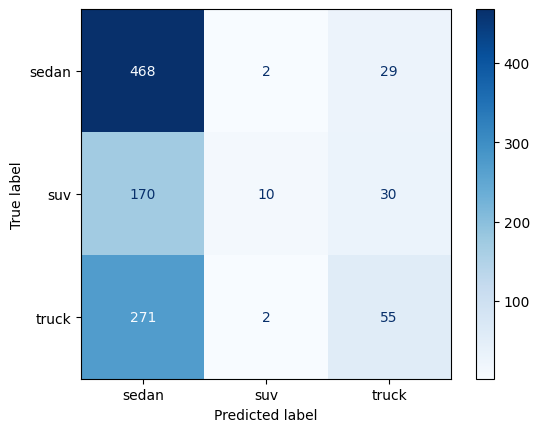

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# cm =confusion_matrix(pd.Series(test_labels_names), pd.Series(y_pred_names), labels=class_names_use)
cm =confusion_matrix(pd.Series(test_labels_names), y_pred_names, labels=class_names_use)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_use)
disp.plot(cmap='Blues')
plt.show()

In [46]:
# del custom_classification_report

from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd
import numpy as np

def custom_classification_report(true_labels, predicted_labels, class_names):
    '''

              precision    recall  f1-score   support

       sedan       0.71      0.70      0.71       499
         suv       0.49      0.26      0.34       210
       truck       0.51      0.67      0.58       328

    accuracy                           0.60      1037
   macro avg       0.57      0.54      0.54      1037
weighted avg       0.60      0.60      0.59      1037
    '''

  # Get precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(true_labels, predicted_labels, labels=class_names, average=None)

    # Compute overall accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)

    # Compute macro and weighted averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    weighted_precision = np.average(precision, weights=support)
    weighted_recall = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)

    # Create a pandas DataFrame for clean formatting
    report_df = pd.DataFrame({
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'support': support
    }, index=class_names)

    # Add the averages and accuracy to the report
    avg_stats = pd.DataFrame({
        'precision': [macro_precision, weighted_precision],
        'recall': [macro_recall, weighted_recall],
        'f1-score': [macro_f1, weighted_f1],
        'support': [np.sum(support), np.sum(support)]  # Total support for both avg rows
    }, index=['macro avg', 'weighted avg'])

    # Add the accuracy row
    accuracy_row = pd.DataFrame({
        'precision': [None],
        'recall': [None],
        'f1-score': [accuracy],
        'support': [len(true_labels)]
    }, index=['accuracy'])

    # Combine the individual class report, accuracy, and average rows
    report_df = pd.concat([report_df, accuracy_row, avg_stats])

    # Format the DataFrame to match the Terraform report style
    report_str = report_df.to_string(formatters={
        'precision': '{:0.2f}'.format,
        'recall': '{:0.2f}'.format,
        'f1-score': '{:0.2f}'.format,
        'support': '{:0.0f}'.format
    })
    report_str=report_str.replace('NaN','   ')
    return report_df, report_str

In [47]:
from _03_train_cnns.vision_model_utils import custom_classification_report

In [48]:
_,report_str= custom_classification_report(
    pd.Series(test_labels_names),
    y_pred_names,
     class_names=class_names_use
)
print(report_str.replace('NaN','   '))

             precision recall f1-score support
sedan             0.51   0.94     0.66     499
suv               0.71   0.05     0.09     210
truck             0.48   0.17     0.25     328
accuracy                          0.51    1037
macro avg         0.57   0.38     0.33    1037
weighted avg      0.54   0.51     0.42    1037


In [49]:
model_folder = '/Users/levgolod/Projects/car_classifier/saved_models/'
timestamp = int(time.time())
model_path = f'{model_folder}02_c_new_model_structure.{timestamp}.keras'
print(model_path)
model.save(model_path)

/Users/levgolod/Projects/car_classifier/saved_models/02_c_new_model_structure.1741047042.keras


In [50]:
# NLP exercise - batch padding to avoid truncating
# stanford video LSTM